# Problem Statement


*   Context and Company Background: TechWorks Consulting, a company specializing in IT talent recruitment, and highlights its unique approach to matching skilled IT professionals with job opportunities.
*   Data Description: The Dataset conatins information about colleges, cities, roles, previous experience, and salary. This information will be used to train and test the predictive model.


*   Regression Task: The primary objective is to perform a regression task, where the aim is to predict a continuous variable, specifically the salary of newly hired employees.
*   Role of Statistics: The role of statistics is to build and check the accuracy of the model.

*  Data Preprocessing: Data Preprocessing is most important task as it involves tasks like handling missing values, outliers, categorical variables, normalization, and feature selection.








# Creating a Salary Prediction Model: A Systematic Approach

*   Data Understanding:
Begin by thoroughly understanding the provided dataset, including its structure, columns, and the meaning of each variable. Gain insights into the data's distribution, summary statistics, and potential outliers.
*   Data Preprocessing:

 *   Handle Missing Values: Identify and address missing data by imputation or removal, ensuring that data is complete.
 *   Outlier Detection and Treatment: Detect and handle outliers in the dataset, which could impact the model's accuracy.
  *   Convert Categorical Data: Transform categorical variables (e.g., "College" and "City") into numerical format.
  *   Normalize Data: Normalize numerical features to bring them to a common scale to avoid any feature dominating the model.

 *  Feature Selection: Use statistical techniques such as Lasso, Ridge, or correlation analysis to select the most relevant features for salary prediction.



*   Performing Exploratory Data Analysis (EDA)

*  Model Selection:

  *   Choose different regression models (e.g., Linear Regression, Multi Linear Regression) to build and evaluate the predictive models.
* Model Training and Evaluation:
 *  Split the dataset into training and testing sets to train the models and assess their performance.

 *   Use appropriate evaluation metrics like Mean Squared Error (MSE), R-squared, and Mean Absolute Error (MAE) to measure the model's accuracy.
 *  Experiment with different
hyperparameters for each model and use cross-validation to avoid overfitting.


*  Model Comparison:
 *  Compare the performance of different models and select the one with the best accuracy and generalization.



*  Further Improvement:
 *  Consider additional techniques for model improvement, such as feature engineering, hyperparameter tuning, and ensemble methods.





  




















# The available ML model options had to perform on this task
**In the task of predicting employee salary at TechWorks Consulting, there are several machine learning model options available for regression tasks. The choice of the model depends on various factors, including the nature of the data, the complexity of the problem, and the need for model interpretability. Here are some of the available ML model options:**


1.   Linear Regression:
 *   Linear regression is a simple and interpretable model that assumes a linear relationship between the features and the target variable (salary). It's a good starting point and can provide baseline performance.
2.   Ridge Regression and Lasso Regression:
 *   Ridge and Lasso regression are regularization techniques that can be used to handle multicollinearity and prevent overfitting. They are variants of linear regression that add regularization terms to the cost function.
3. Decision Trees:
   * Decision tree-based models, like   Random Forest and Gradient Boosting, are capable of capturing non-linear relationships in the data. They can handle both numerical and categorical features and automatically deal with feature importance.
4. K-Nearest Neighbors (KNN):
  *   KNN is a non-parametric method that makes predictions based on the average of the 'k' nearest data points. It can be effective for small to medium-sized datasets.
5. Polynomial Regression:
 *  Polynomial regression can be used to capture non-linear relationships by introducing polynomial features.

In these 5 models, I will be performing only 3 of them with default parameters and with somes doing changes in parameter












In [1]:
# Import the pandas library for data manipulation and analysis
# Import the numpy library for numerical operations and array processing
# Import the seaborn library for data visualization

import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Read a CSV file into a DataFrame
df=pd.read_csv("/content/drive/MyDrive/ML_Project files/ML case Study.csv")
clg=pd.read_csv("/content/drive/MyDrive/ML_Project files/Colleges.csv")
cts=pd.read_csv("/content/drive/MyDrive/ML_Project files/cities.csv")

In [ ]:
# Overview of Data
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,SVNIT Surat,Asansol,Manager,55523.0,3,66,19,71406.58
1,NIT Bhopal,Ajmer,Executive,57081.0,1,84,18,68005.87
2,"IEM, Kolkata",Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,"KIIT, Bhubaneswar",Ajmer,Executive,49010.0,2,81,33,82092.39
4,DTU,Durgapur,Executive,57879.0,4,74,32,73878.10


In [ ]:
df.shape

(1589, 8)

In [ ]:
# Overview of College data
clg.head()

,Tier 1,Tier 2,Tier 3
0,IIT Bombay,IIIT Bangalore,"Ramaiah Institute of Technology, Bengaluru"
1,IIT Delhi,IIIT Delhi,TIET/Thapar University
2,IIT Kharagpur,IGDTUW,Manipal Main Campus
3,IIT Madras,NIT Calicut,VIT Vellore
4,IIT Kanpur,IIITM Gwalior,SRM Main Campus


In [ ]:
clg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tier 1  22 non-null     object
 1   Tier 2  28 non-null     object
 2   Tier 3  19 non-null     object
dtypes: object(3)
memory usage: 800.0+ bytes


In [ ]:
# Overview of City data
cts.head()

,Metrio City,non-metro cities
0,Mumbai,Dehradun
1,Delhi,Durgapur
2,Kolkata,Asansol
3,Chennai,Rourkela
4,Bangalore,Kozhikode


In [3]:
#Extract data from the "Tier 1," "Tier 2," and "Tier 3" columns of the 'college' DataFrame
#and store them in separate lists T1,T2,T3 for further analysis.

T1 = clg["Tier 1"].tolist()
T2 = clg["Tier 2"].tolist()
T3 = clg["Tier 3"].tolist()


In [ ]:
T1

['IIT Bombay',
 'IIT Delhi',
 'IIT Kharagpur',
 'IIT Madras',
 'IIT Kanpur',
 'IIT Roorkee',
 'IIT Guwahati',
 'IIIT Hyderabad',
 'BITS Pilani (Pilani Campus)',
 'IIT Indore',
 'IIT Ropar',
 'IIT BHU (Varanasi)',
 'IIT ISM Dhanbad',
 'DTU',
 'NSUT Delhi (NSIT)',
 'NIT Tiruchipally (Trichy)',
 'NIT Warangal',
 'NIT Surathkal (Karnataka)',
 'Jadavpur University',
 'BITS Pilani (Hyderabad Campus)',
 'BITS Pilani (Goa Campus)',
 'IIIT Allahabad',
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

In [4]:
for i in df.College:
  if i in T1:
    df["College"].replace(i,3,inplace=True)
  elif i in T2:
    df["College"].replace(i,2,inplace=True)
  elif i in T3:
    df["College"].replace(i,1,inplace=True)


In [ ]:
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,Asansol,Manager,55523.0,3,66,19,71406.58
1,2,Ajmer,Executive,57081.0,1,84,18,68005.87
2,1,Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,1,Ajmer,Executive,49010.0,2,81,33,82092.39
4,3,Durgapur,Executive,57879.0,4,74,32,73878.10


In [5]:
metro_city=cts["Metrio City"].tolist()
non_metro_city=cts["non-metro cities"].tolist()

In [ ]:
metro_city

['Mumbai',
 'Delhi',
 'Kolkata',
 'Chennai',
 'Bangalore',
 'Hyderabad',
 'Ahmedabad',
 'Pune',
 'Surat']

In [6]:
for i in df.City:
  if i in metro_city:
    df["City"].replace(i,1,inplace=True)
  elif i in non_metro_city:
    df["City"].replace(i,0,inplace=True)

In [ ]:
df.head(100)

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,0,Manager,55523.0,3,66,19,71406.58
1,2,0,Executive,57081.0,1,84,18,68005.87
2,1,0,Executive,60347.0,2,52,28,76764.02
3,1,0,Executive,49010.0,2,81,33,82092.39
4,3,0,Executive,57879.0,4,74,32,73878.10
...,...,...,...,...,...,...,...,...
95,3,1,Executive,59707.0,3,70,28,56003.61
96,2,1,Executive,57726.0,4,84,54,68673.29
97,3,1,Executive,58401.0,4,45,55,76028.50
98,3,0,Manager,41228.0,2,64,56,87418.05


In [7]:
#Converting Categorical Column in Numerical
df=pd.get_dummies(df,columns=["Role"],drop_first=True)

In [ ]:
df.head()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
0,2,0,55523.0,3,66,19,71406.58,1
1,2,0,57081.0,1,84,18,68005.87,0
2,1,0,60347.0,2,52,28,76764.02,0
3,1,0,49010.0,2,81,33,82092.39,0
4,3,0,57879.0,4,74,32,73878.10,0


In [8]:
df['Role_Manager']=df['Role_Manager'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   int64  
 1   City                 1589 non-null   int64  
 2   Previous CTC         1589 non-null   float64
 3   Previous job change  1589 non-null   int64  
 4   Graduation Marks     1589 non-null   int64  
 5   EXP (Month)          1589 non-null   int64  
 6   CTC                  1589 non-null   float64
 7   Role_Manager         1589 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 99.4 KB


In [ ]:
df.describe()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,2.024544,0.514160,55518.453744,2.528634,59.855255,39.044682,75353.278798,0.206419
std,0.838330,0.499957,6655.218445,1.123918,14.935139,14.108875,12587.288237,0.404862
min,1.000000,0.000000,36990.000000,1.000000,35.000000,18.000000,53020.320000,0.000000
25%,1.000000,0.000000,50518.000000,2.000000,46.000000,26.000000,66902.350000,0.000000
50%,2.000000,1.000000,55291.000000,3.000000,60.000000,39.000000,73028.670000,0.000000
75%,3.000000,1.000000,60109.000000,4.000000,73.000000,51.000000,80588.670000,0.000000
max,3.000000,1.000000,77911.000000,4.000000,85.000000,64.000000,123416.990000,1.000000


# Detecting Outliers

<Axes: ylabel='CTC'>

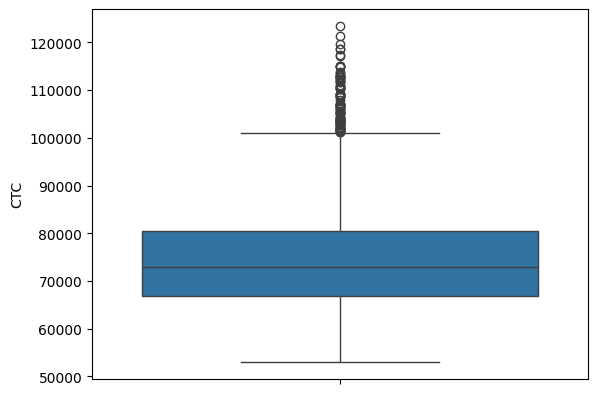

In [ ]:
sns.boxplot(df['CTC'])

<Axes: ylabel='Previous CTC'>

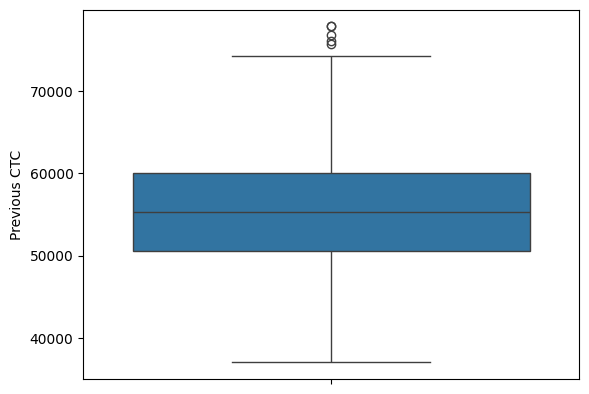

In [ ]:
sns.boxplot(df['Previous CTC'])


<Axes: ylabel='Graduation Marks'>

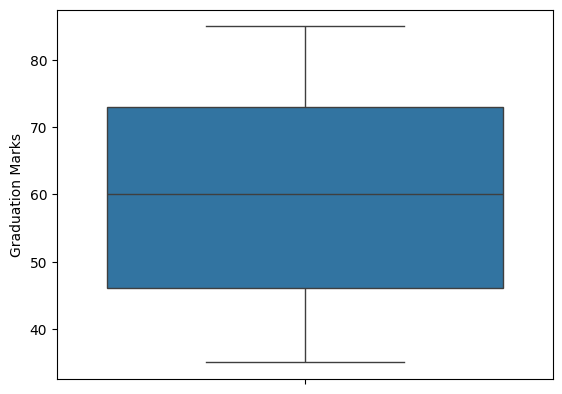

In [ ]:
sns.boxplot(df['Graduation Marks'])


<Axes: ylabel='EXP (Month)'>

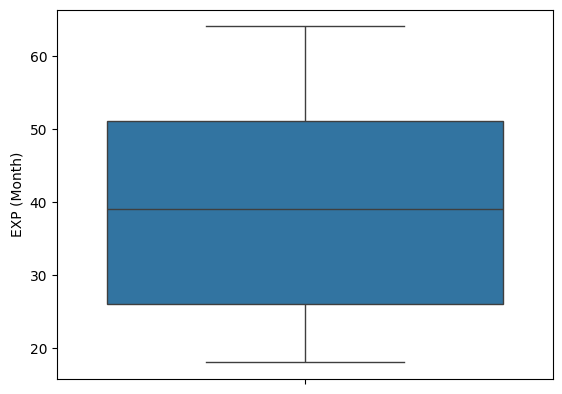

In [ ]:
sns.boxplot(df['EXP (Month)'])

<Axes: >

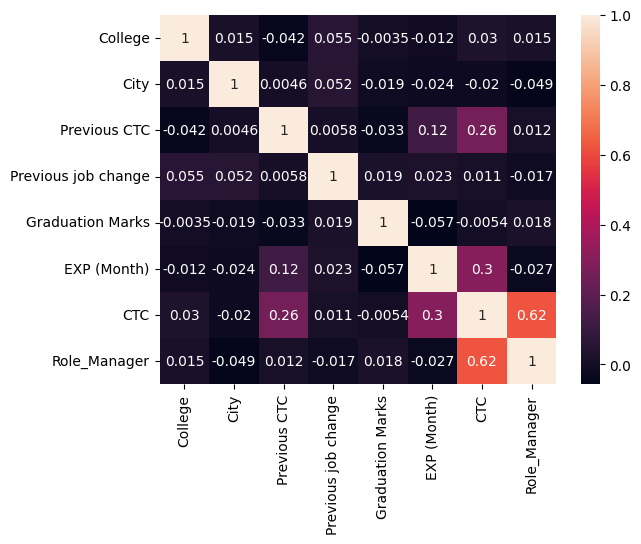

In [ ]:
#Finding Co-relation
corr=df.corr()
sns.heatmap(corr,annot=True)

**Removing Outliers**

**Outliers in Previous CTC column**:
 In the box plot of "Previous CTC" column.As seen outliera are not too extreme,so keeping this data does not affect the model much.

**Outliers present in CTC column**

In [9]:
per25 = df['CTC'].quantile(0.25)
per75 = df['CTC'].quantile(0.75)
iqr = per75-per25
upper_limit = per75 + 1.5*iqr
lower_limit = per25 - 1.5*iqr

In [10]:
df[(df['CTC'] < lower_limit) | (df['CTC'] > upper_limit)]

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
14,1,0,66487.0,1,50,27,103595.83,1
29,2,0,65172.0,1,44,31,107138.14,1
30,3,0,58529.0,1,65,22,102763.61,1
34,3,0,60894.0,4,80,28,118651.89,1
38,2,0,57485.0,1,77,35,103774.34,1
...,...,...,...,...,...,...,...,...
1447,1,0,59099.0,2,67,63,103305.30,1
1461,3,0,55440.0,4,72,44,112826.26,1
1513,1,0,58639.0,2,46,63,109108.12,1
1523,2,1,70258.0,4,38,36,115126.75,1


As seen above, these are some outliers in "CTC" column but they are not as extreme that can make any huge difference while making prediction. Therefore in my opinion keeping those outliers into data is more useful than removing.

**Conclusion on detection of Outliers:**


*   There were as such no extreme outliers present in our dataset that can make any huge difference in machine learning model. Also from describe function it is clear that there is no extreme outliers.
* As seen above in "Previous CTC" and "CTC", there are some outliers but from my perspective these are not going to affect my model.

*  In the HeatMap figure, there are some relation between Role_manager and CTC and Previous CTC and CTC






# Applying Machine Learning models without Feature Scaling

In ML,I am going to applying all possible algorithm without any scaling to check performance of model

In [11]:
#Import necessary libraries for data splitting, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
X =df.drop(['CTC'],axis=1)
y = df['CTC']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

In [ ]:
X_train.shape

(1271, 7)

Linear Regression Model

In [ ]:
lnr_reg=LinearRegression()
lnr_reg.fit(X_train,y_train)
r2score=r2_score(y_test,lnr_reg.predict(X_test))
mae=mean_absolute_error(y_test,lnr_reg.predict(X_test))
mse=mean_squared_error(y_test,lnr_reg.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lnr_reg.coef_)
print("Intercept:",lnr_reg.intercept_)

R2_Score: 0.5870178888902512
MAE: 6325.5203828324375
MSE: 63723298.81383873
Coeff: [5.40751442e+02 6.33847914e+02 4.04139351e-01 1.25974001e+02
 4.19996993e+00 2.57029957e+02 1.91999568e+04]
Intercept: 36871.27294400646


In [ ]:
#Ridge Regression Model
ridge=Ridge()
ridge.fit(X_train,y_train)
r2score=r2_score(y_test,ridge.predict(X_test))
mae=mean_absolute_error(y_test,ridge.predict(X_test))
mse=mean_squared_error(y_test,ridge.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",ridge.coef_)
print("Intercept:",ridge.intercept_)

R2_Score: 0.5867397716983087
MAE: 6328.058933223056
MSE: 63766212.40367872
Coeff: [5.41544504e+02 6.28176343e+02 4.04150461e-01 1.25539771e+02
 4.18161042e+00 2.56999750e+02 1.91084353e+04]
Intercept: 36894.38517461916


In [ ]:
#Ridge Regression model with alpha specified value
ridge_tuned=Ridge(alpha=0.5,solver='auto')
ridge_tuned.fit(X_train,y_train)
r2score=r2_score(y_test,ridge_tuned.predict(X_test))
mae=mean_absolute_error(y_test,ridge_tuned.predict(X_test))
mse=mean_squared_error(y_test,ridge_tuned.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",ridge_tuned.coef_)
print("Intercept:",ridge_tuned.intercept_)

R2_Score: 0.5868806603534372
MAE: 6326.758014312518
MSE: 63744473.22992586
Coeff: [5.41149924e+02 6.31003182e+02 4.04144922e-01 1.25756407e+02
 4.19076750e+00 2.57014818e+02 1.91540865e+04]
Intercept: 36882.855537908785


In [ ]:
#Lasso Rgreession Model
lasso=Lasso()
lasso.fit(X_train,y_train)
r2score=r2_score(y_test,lasso.predict(X_test))
mae=mean_absolute_error(y_test,lasso.predict(X_test))
mse=mean_squared_error(y_test,lasso.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lasso.coef_)
print("Intercept:",lasso.intercept_)

R2_Score: 0.5870186312432404
MAE: 6325.53000103954
MSE: 63723184.26848655
Coeff: [5.39547528e+02 6.29743894e+02 4.04133354e-01 1.25288083e+02
 4.19236273e+00 2.57017879e+02 1.91936863e+04]
Intercept: 36880.12837764868


In [ ]:
#Lasso Regression with aplha value
lasso_tuned=Lasso(alpha=0.5)
lasso_tuned.fit(X_train,y_train)
r2score=r2_score(y_test,lasso_tuned.predict(X_test))
mae=mean_absolute_error(y_test,lasso_tuned.predict(X_test))
mse=mean_squared_error(y_test,lasso_tuned.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lasso_tuned.coef_)
print("Intercept:",lasso_tuned.intercept_)

R2_Score: 0.5870182783170101
MAE: 6325.525188358902
MSE: 63723238.725139834
Coeff: [5.40149579e+02 6.31795840e+02 4.04136354e-01 1.25631042e+02
 4.19616589e+00 2.57023918e+02 1.91968215e+04]
Intercept: 36875.70047180094


# Applying Decision Tree

In [12]:
#Importing DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
#Creating a DecisionTreeRegressor Model
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)
r2score=r2_score(y_test,dtr.predict(X_test))
mae=mean_absolute_error(y_test,dtr.predict(X_test))
mse=mean_squared_error(y_test,dtr.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",dtr.feature_importances_)

R2_Score: 0.3688229405299166
MAE: 7301.376918238995
MSE: 97390863.3886654
Coeff: [0.02333939 0.01586147 0.29975195 0.03475309 0.08713997 0.16090282
 0.37825132]


In [ ]:
#Creating DecisionTree with max depth
dtr_max=DecisionTreeRegressor(max_depth=3)
dtr_max.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,dtr_max.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,dtr_max.predict(X_test)))
print("MSE:",mean_squared_error(y_test,dtr_max.predict(X_test)))

R2_Score: 0.6432112723482899
MAE: 5941.274538750732
MSE: 55052638.102083035


In [13]:
#Import Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
#Creating Random Forest Regression
rnd=RandomForestRegressor()
rnd.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,rnd.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,rnd.predict(X_test)))
print("MSE:",mean_squared_error(y_test,rnd.predict(X_test)))

R2_Score: 0.6831092341790298
MAE: 5525.400458176097
MSE: 48896367.22397779


In [ ]:
#RandomForest with tuned parameters
rnd_tuned=RandomForestRegressor(n_estimators=2000,max_depth=5,min_samples_split=3)
rnd_tuned.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,rnd_tuned.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,rnd_tuned.predict(X_test)))
print("MSE:",mean_squared_error(y_test,rnd_tuned.predict(X_test)))

R2_Score: 0.6706779982385768
MAE: 5753.122404896133
MSE: 50814511.717767514


In [ ]:
#Giving Parameter throught GridSearch
params_grid={"max_depth":[3,7,10],
             "min_samples_split":[4,5,10],
             "max_features":[4,7,10]}

In [ ]:
#finding Best parameter
grid_search=GridSearchCV(rnd_tuned,params_grid,cv=5)

In [ ]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestRegressor(max_depth=5, min_samples_split=3,
                                             n_estimators=2000),
             param_grid={'max_depth': [3, 7, 10], 'max_features': [4, 7, 10],
                         'min_samples_split': [4, 5, 10]})

In [ ]:
#Best Parameter
grid_search.best_params_

{'max_depth': 10, 'max_features': 4, 'min_samples_split': 4}

# Checking model performance with test size=0.1


In [ ]:
#split Data into train and test with test_size 0.1
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=25)

In [ ]:
#Create Linear Regression model with test size=0.1
lnr_reg=LinearRegression()
lnr_reg.fit(X_train,y_train)
r2score=r2_score(y_test,lnr_reg.predict(X_test))
mae=mean_absolute_error(y_test,lnr_reg.predict(X_test))
mse=mean_squared_error(y_test,lnr_reg.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lnr_reg.coef_)
print("Intercept:",lnr_reg.intercept_)

R2_Score: 0.6083593219832865
MAE: 6742.6413490255345
MSE: 66280905.07715873
Coeff: [5.06615692e+02 7.51929581e+02 3.95186984e-01 1.31685933e+02
 3.59291879e+00 2.62102220e+02 1.92829766e+04]
Intercept: 37235.001803048195


In [ ]:
#Create Ridge REgression with test size=0.1
ridge=Ridge()
ridge.fit(X_train,y_train)
r2score=r2_score(y_test,ridge.predict(X_test))
mae=mean_absolute_error(y_test,ridge.predict(X_test))
mse=mean_squared_error(y_test,ridge.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",ridge.coef_)
print("Intercept:",ridge.intercept_)

R2_Score: 0.6080486890105539
MAE: 6744.776266088652
MSE: 66333476.31333315
Coeff: [5.06741871e+02 7.46483392e+02 3.95219124e-01 1.31485856e+02
 3.60072177e+00 2.62044471e+02 1.92007878e+04]
Intercept: 37255.01884298455


In [ ]:
#Ridge Regression model with alpha specified value 0.5 and ts=0.1
ridge_tuned=Ridge(alpha=0.5,solver='auto')
ridge_tuned.fit(X_train,y_train)
r2score=r2_score(y_test,ridge_tuned.predict(X_test))
mae=mean_absolute_error(y_test,ridge_tuned.predict(X_test))
mse=mean_squared_error(y_test,ridge_tuned.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",ridge_tuned.coef_)
print("Intercept:",ridge_tuned.intercept_)

R2_Score: 0.6082052846166792
MAE: 6743.710997687746
MSE: 66306974.218204394
Coeff: [5.06679511e+02 7.49199066e+02 3.95203090e-01 1.31585736e+02
 3.59682721e+00 2.62073284e+02 1.92417943e+04]
Intercept: 37245.031171340044


In [ ]:
#Lasso Regression with ts=0.1
lasso=Lasso()
lasso.fit(X_train,y_train)
r2score=r2_score(y_test,lasso.predict(X_test))
mae=mean_absolute_error(y_test,lasso.predict(X_test))
mse=mean_squared_error(y_test,lasso.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lasso.coef_)
print("Intercept:",lasso.intercept_)

R2_Score: 0.6083818405323134
MAE: 6742.409499104685
MSE: 66277094.058808744
Coeff: [5.05329445e+02 7.47763282e+02 3.95185192e-01 1.30995685e+02
 3.58507087e+00 2.62086664e+02 1.92766415e+04]
Intercept: 37243.945097638585


In [ ]:
lasso_tuned=Lasso(alpha=0.5)
lasso_tuned.fit(X_train,y_train)
r2score=r2_score(y_test,lasso_tuned.predict(X_test))
mae=mean_absolute_error(y_test,lasso_tuned.predict(X_test))
mse=mean_squared_error(y_test,lasso_tuned.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",lasso_tuned.coef_)
print("Intercept:",lasso_tuned.intercept_)

R2_Score: 0.6083706029958484
MAE: 6742.525405336947
MSE: 66278995.88905657
Coeff: [5.05972636e+02 7.49846120e+02 3.95186090e-01 1.31340834e+02
 3.58899267e+00 2.62094441e+02 1.92798090e+04]
Intercept: 37239.47347107423


Decision Tree creation using test size=0.1

In [ ]:
#Creating a DecisionTreeRegressor Model
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)
r2score=r2_score(y_test,dtr.predict(X_test))
mae=mean_absolute_error(y_test,dtr.predict(X_test))
mse=mean_squared_error(y_test,dtr.predict(X_test))
print("R2_Score:",r2score)
print("MAE:",mae)
print("MSE:",mse)
print("Coeff:",dtr.feature_importances_)

R2_Score: 0.5060681204586945
MAE: 6772.0232075471695
MSE: 83592573.14191133
Coeff: [0.01418618 0.00872964 0.29432372 0.03580826 0.10020811 0.1662434
 0.38050069]


In [ ]:
dtr_max=DecisionTreeRegressor(max_depth=3)
dtr_max.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,dtr_max.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,dtr_max.predict(X_test)))
print("MSE:",mean_squared_error(y_test,dtr_max.predict(X_test)))

R2_Score: 0.670469222420453
MAE: 6152.244900476473
MSE: 55769483.13785769


In [ ]:
#Creating Random Forest Regression
rnd=RandomForestRegressor()
rnd.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,rnd.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,rnd.predict(X_test)))
print("MSE:",mean_squared_error(y_test,rnd.predict(X_test)))

R2_Score: 0.6973380503287896
MAE: 5883.63657232704
MSE: 51222227.62511198


In [ ]:
#RandomForest with tuned parameters
rnd_tuned=RandomForestRegressor(n_estimators=2000,max_depth=10,min_samples_split=4,max_features=4)
rnd_tuned.fit(X_train,y_train)
print("R2_Score:",r2_score(y_test,rnd_tuned.predict(X_test)))
print("MAE:",mean_absolute_error(y_test,rnd_tuned.predict(X_test)))
print("MSE:",mean_squared_error(y_test,rnd_tuned.predict(X_test)))

R2_Score: 0.692448051497349
MAE: 6028.8227528421685
MSE: 52049806.49157565


# Performing Feature Scaling

In [ ]:
#Split data into X=independent and y=dependent variables
X=df.drop(['CTC'],axis=1)
y=df['CTC']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=25)

In [14]:
#Import Standard Scaler
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
# Storing otput of X_train_scaled into dataframe for checking change done on values after scaling
df_X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_X_test = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [ ]:
# Statistical changes sfter scaling
np.round(df_X_train.describe(), 1)

# Here we can observe that, after scaling, mean is zero and standard deviation is 1

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),Role_Manager
count,1271.0,1271.0,1271.0,1271.0,1271.0,1271.0,1271.0
mean,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.2,-1.0,-2.8,-1.4,-1.7,-1.5,-0.5
25%,-1.2,-1.0,-0.8,-1.4,-0.9,-0.9,-0.5
50%,-0.1,1.0,-0.0,0.4,0.1,-0.0,-0.5
75%,1.1,1.0,0.7,1.3,0.9,0.9,-0.5
max,1.1,1.0,3.3,1.3,1.7,1.8,1.9


# Checking Model performance after scaling with test size=0.2

In [ ]:
#Creating LinearRegression Model with scaled data and ts=0.2
lr_scaled=LinearRegression()
lr_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,lr_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,lr_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,lr_scaled.predict(X_test_scaled)))
print("Coeff:",lr_scaled.coef_)
print("Intercept:",lr_scaled.intercept_)

R2_Score: 0.5870178888902535
MAE: 6325.520382832407
MSE: 63723298.813838355
Coeff: [ 453.1221954   316.8806952  2704.65732665  142.76467799   62.31632838
 3651.51865779 7799.67717036]
Intercept: 75360.20060582219


In [ ]:
#Create Ridge Regressor after scaling
r_scaled=Ridge()
r_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,r_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,r_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,r_scaled.predict(X_test_scaled)))
print("Coeff:",r_scaled.coef_)
print("Intercept:",r_scaled.intercept_)

R2_Score: 0.5869582606251909
MAE: 6326.023813859595
MSE: 63732499.47810474
Coeff: [ 452.81530882  316.24524038 2702.8061546   142.65826465   62.05188385
 3648.74529187 7793.49611489]
Intercept: 75360.20060582219


In [ ]:
#Create Lasso Regressor model after scaling
l_scaled=Lasso()
l_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,l_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,l_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,l_scaled.predict(X_test_scaled)))
print("Coeff:",l_scaled.coef_)
print("Intercept:",l_scaled.intercept_)

R2_Score: 0.5870131484970971
MAE: 6325.589414718666
MSE: 63724030.258328274
Coeff: [ 452.16687291  315.85608045 2703.71425296  141.86788974   61.23806392
 3650.50057147 7798.62628407]
Intercept: 75360.20060582219


In [ ]:
#Creating decision Tree regression
dtr_scaled=DecisionTreeRegressor()
dtr_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,dtr_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,dtr_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,dtr_scaled.predict(X_test_scaled)))

R2_Score: 0.35019872442922706
MAE: 7372.623459119498
MSE: 100264587.10654905


In [ ]:
#Creating Random Forest Regressor model
rnd_scaled=RandomForestRegressor()
rnd_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,rnd_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,rnd_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,rnd_scaled.predict(X_test_scaled)))

R2_Score: 0.6829564021098534
MAE: 5559.112989308175
MSE: 48919949.271118514


In [ ]:
#Creating Random Forest model after feature scaling with parameter tuning
rnd_tuned_scaled=RandomForestRegressor(n_estimators=2000,max_depth=10,min_samples_split=4,max_features=4)
rnd_tuned_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,rnd_tuned_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,rnd_tuned_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,rnd_tuned_scaled.predict(X_test)))


R2_Score: 0.6914527697301289
MAE: 5593.7935529930155
MSE: 218197893.93228787


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Performing Feature scaling on test size=0.1

In [15]:
X=df.drop(['CTC'],axis=1)
y=df['CTC']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=25)

In [20]:
scalar=StandardScaler()

In [21]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
#Creating LinearRegression Model with scaled data and ts=0.1
lr_scaled=LinearRegression()
lr_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,lr_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,lr_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,lr_scaled.predict(X_test_scaled)))
print("Coeff:",lr_scaled.coef_)
print("Intercept:",lr_scaled.intercept_)

R2_Score: 0.6083593219832897
MAE: 6742.641349025486
MSE: 66280905.077158175
Coeff: [ 423.68369014  375.94677231 2632.15171413  147.68126589   53.25941756
 3696.74285924 7812.50699661]
Intercept: 75389.49174825175


In [23]:
#Create Ridge Regressor after scaling and ts=0.1
r_scaled=Ridge()
r_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,r_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,r_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,r_scaled.predict(X_test_scaled)))
print("Coeff:",r_scaled.coef_)
print("Intercept:",r_scaled.intercept_)

R2_Score: 0.6082938383882213
MAE: 6743.26236380046
MSE: 66291987.46004757
Coeff: [ 423.34537877  375.31588279 2630.58403452  147.64551436   53.0671897
 3694.16618183 7806.97409414]
Intercept: 75389.49174825175


In [24]:
#Create Lasso Regressor model after scaling and ts=0.1
l_scaled=Lasso()
l_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,l_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,l_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,l_scaled.predict(X_test_scaled)))
print("Coeff:",l_scaled.coef_)
print("Intercept:",l_scaled.intercept_)

R2_Score: 0.6083602931463343
MAE: 6742.672565490771
MSE: 66280740.71842532
Coeff: [ 422.70190947  374.86253188 2631.20234938  146.81185706   52.16395664
 3695.71068438 7811.44976888]
Intercept: 75389.49174825175


In [25]:
#Creating decision Tree regression after scaling and ts=0.1
dtr_scaled=DecisionTreeRegressor()
dtr_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,dtr_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,dtr_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,dtr_scaled.predict(X_test_scaled)))

R2_Score: 0.4920578754916337
MAE: 6972.834402515723
MSE: 85963654.00478806


In [26]:
#Creating Random Forest model after feature scaling with parameter tuning and ts=0.1
rnd_tuned_scaled=RandomForestRegressor(n_estimators=2000,max_depth=10,min_samples_split=4,max_features=4)
rnd_tuned_scaled.fit(X_train_scaled,y_train)
print("R2_Score:",r2_score(y_test,rnd_tuned_scaled.predict(X_test_scaled)))
print("MAE:",mean_absolute_error(y_test,rnd_tuned_scaled.predict(X_test_scaled)))
print("MSE:",mean_squared_error(y_test,rnd_tuned_scaled.predict(X_test)))

R2_Score: 0.6955662632649676
MAE: 6008.416842517422
MSE: 268964334.73256975


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


To compare the performance of different machine learning models, we'll focus on the R-squared (r2_score) metric, which measures the goodness of fit of the models. A higher R-squared indicates a better fit to the data. Additionally, we'll consider Mean Absolute Error (MAE) and Mean Squared Error (MSE) for reference.

Here's a summary of the model performance in the four scenarios:

**Scenario 1 (Test size = 0.2):**


*   Linear Regression: r2_score=0.5870

*   Ridge: r2_score=0.5867

*   Lasso: r2_score =0.5870
*  Decision Tree: r2_score =0.3688


*   Random Forest: r2_score =0.6706






**Scenario 2 (Test size = 0.1):**
*   Linear Regression: r2_score=0.6083

*   Ridge: r2_score=0.6082

*   Lasso: r2_score =0.6083
*  Decision Tree: r2_score =


*   Random Forest: r2_score =0.6924

**Scenario 3 (Test size = 0.1 with feature scaling):**
*   Linear Regression: r2_score=0.6083

*   Ridge: r2_score=0.6082

*   Lasso: r2_score =0.6083
*  Decision Tree: r2_score =0.4920


*   Random Forest: r2_score =0.6955


**Scenario 4 (Test size = 0.2 with feature scaling):**
 *   Linear Regression: r2_score=0.5870

*   Ridge: r2_score=0.5868

*   Lasso: r2_score =0.5870
*  Decision Tree: r2_score =0.3501


*   Random Forest: r2_score =0.6914

**Summary:**


*   Among the different models, Random Forest consistently performs well in all scenarios with or without feature scaling, and with varying test sizes. It achieves the highest R-squared scores, indicating a good fit to the data.
*   Linear Regression and Lasso also perform well but with slightly lower R-squared scores compared to Random Forest.
*  Decision Tree, on the other hand, has the lowest R-squared scores and performs the worst among the models in all scenarios.


*  Feature scaling appears to have a positive impact on model performance, as evidenced by the higher R-squared scores in scenarios with feature scaling compared to those without.


# To further improve the performance of selected model, I can take several steps:


*  **Increase the Number of Trees (Estimators):** Random Forest's performance often benefits from increasing the number of decision trees (estimators) in the ensemble.

*   **Tune Hyperparameters:** Perform a more thorough hyperparameter tuning by experimenting with different values for parameters like max_depth, min_samples_split, min_samples_leaf, and max_features. Grid Search or Randomized Search can help find the optimal combination of hyperparameters.
*  **Feature Selection:** Consider removing or reducing the importance of less informative features to improve the model's efficiency and potentially its performance.




